# Does the grain market really have a spring high and a harvest low? 🌾
### The old-crop/new-crop calendar — a century-old trading floor legend, tested on the three ETFs anyone can actually buy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Grain traders have talked about this one forever: *plant the crop in spring, and nobody knows yet whether the weather will cooperate* — so prices carry a little insurance premium through planting, pollination and (for winter wheat) the spring green-up. Then the crop comes in. All at once, every elevator in the Midwest fills up, and the **harvest-time low** arrives on schedule, every single year.

It's a great story — it even has a textbook mechanism (the "theory of storage": old-crop stocks get scarce right before harvest, then flush right after). So we tested it, on CORN, WEAT and SOYB — the three ETFs a retail account can actually hold — from 2011 to 2026.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni table and the roll-drag math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Each grain's "spring" and "harvest" windows come from USDA's own published crop-progress calendar — hardcoded facts, not a fit. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from grain_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    ETF, FUT = data.load_real()
    MONTHLY = {g: st.monthly_log_returns(ETF[g]) for g in data.GRAINS}
    FUT_MONTHLY = {g: st.monthly_log_returns(FUT[g]) for g in data.GRAINS}
else:
    ETF = FUT = MONTHLY = FUT_MONTHLY = None
print("real cache present:", HAVE_REAL, "| grains:", data.GRAINS,
      "| months/grain:", (0 if MONTHLY is None else {g: len(MONTHLY[g]) for g in data.GRAINS}))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-10-03', 'end': '2026-06-30', 'n_months': 176, 'bonf_crit': 4.05, 'bonf_survive': 0, 'bonf_n': 36, 'best': {'corn': (10, 1.37, 1.6), 'wheat': (10, 0.96, 1.8), 'soy': (10, 1.26, 1.05)}, 'worst': {'corn': (7, -2.45, -0.98), 'wheat': (8, -3.21, -1.68), 'soy': (7, -1.53, -1.13)}, 'top_hac': {'wheat_nov': -2.78, 'corn_nov': -2.45, 'wheat_aug': -2.27}, 'sh': {'corn': (-2.29, 29, -0.38, 43, -1.92, -1.2), 'wheat': (0.2, 45, -2.1, 29, 2.3, 1.13), 'soy': (-1.03, 28, -0.02, 43, -1.01, -0.84)}, 'pooled_spring': -0.85, 'pooled_harvest': -0.68, 'pooled_spread': -0.17, 'pooled_t': -0.19, 'pooled_n_spring': 102, 'pooled_n_harvest': 115, 'ci_lo': -1.97, 'ci_hi': 1.75, 'ci_boot': 5000, 'drag': {'corn': (-53.8, -25.5, -28.3, -0.89), 'wheat': (-94.8, -4.5, -90.3, -5.09), 'soy': (5.3, -4.4, 9.8, 0.45)}, 'timer': {'corn': (-0.35, -7.8, -0.25, -4.3, -0.28, -4.6), 'wheat': (-0.49, -13.2, 0.27, 3.3, 0.25, 2.9), 'soy': (0.04, -0.8, -0.18, -2.4, -0.22, -2.8), 'pooled': (-0.34, -6.9, -0.03, -0.5, -0.08, -0.8)}, 'hit_k': 100, 'hit_n': 216, 'hit_rate': 46.3, 'hit_lo': 39.8, 'hit_hi': 53.0, 'hit_t': -0.09, 'syn_null_mean': 0.36, 'syn_null_sd': 1.02, 'syn_null_fire': 1, 'syn_planted_t': 5.64, 'fp_corn': '81eafd725d20', 'fp_wheat': '38378019b4f4', 'fp_soy': 'a1a9d64ef5f8', 'fp_zc': '1d148da3b3a1', 'fp_zw': '6b8a61301bbf', 'fp_zs': 'c488e2ab74e4'}


real cache present: True | grains: ('corn', 'wheat', 'soy') | months/grain: {'corn': 176, 'wheat': 176, 'soy': 176}


## The answer first

| Question | Answer |
|---|---|
| Is spring really more expensive than harvest? | **Not on this tape.** Pooled across all three grains, spring months average **-0.17%** *less* than harvest months (not the other way around), and that tiny gap could easily be zero (its uncertainty band runs from -1.97% to +1.75%). |
| What's the single best calendar month, then? | **October — for all three grains at once.** Which is *inside* the calendar's own harvest window, not the spring scare window the story predicts. |
| Can you at least trade the *idea* — long spring, short harvest? | On paper, sort of — mostly by sitting in cash half the year on ETFs that have lost money on average. Test the *active* trades on their own and they hit **46%** of the time — a coin flip, and not even a lucky one. |
| Is there a real cost hiding underneath all this? | **Yes, a big one.** WEAT alone gives back **90 basis points every month** to its own roll mechanics — more than any seasonal in this study is worth. |

> The legend is older than any of these ETFs. The ETFs don't know the legend.

## 1 · The claim

> *"Grain prices rally into planting and pollination — a spring 'weather market' where every drought scare or late frost gets priced in — and give it all back at harvest, when new supply floods the market. Buy the scare, sell the combine."*

It's not just floor talk. Economists have documented a real seasonal cycle in storage costs and futures curves tied to the harvest calendar (the "theory of storage" literature). The mechanism is real. The question is whether it survives in the actual instrument a retail trader would use.

## 2 · So what?

If this pattern is real and tradable, it's about as clean a calendar trade as exists: three uncorrelated-ish crops, a mechanism with a hundred years of academic support, and three liquid ETFs anyone can buy with no futures account. If it's *not* real — or real but eaten alive by ETF roll costs — that's an equally useful answer: it tells you why "everyone knows" a seasonal that nobody can actually bank.

## 3 · How would we even know?

- **The calendar.** USDA's own crop-progress windows for corn, wheat and soybeans — planting, the weather-risk stretch, and harvest — hardcoded, not fitted.
- **The comparison.** Every calendar month's average ETF return, for all three grains — 36 numbers — checked against a strict bar that accounts for testing 36 things at once (Bonferroni), so a single lucky month can't sneak through.
- **The trade check.** Buy the spring window, short the harvest window, sit in cash otherwise — costs included — and separately ask: on the months the trade is actually *on*, does it win more than half the time?
- **The roll check.** Compare each ETF's own return to a simple futures-splice spot proxy, to see how much the ETF's own mechanics already eat before any seasonal math even starts.

## 4 · The teardown — let's actually look

**First, the headline.** Average return in the spring "weather-scare" window vs the harvest window, for each grain.

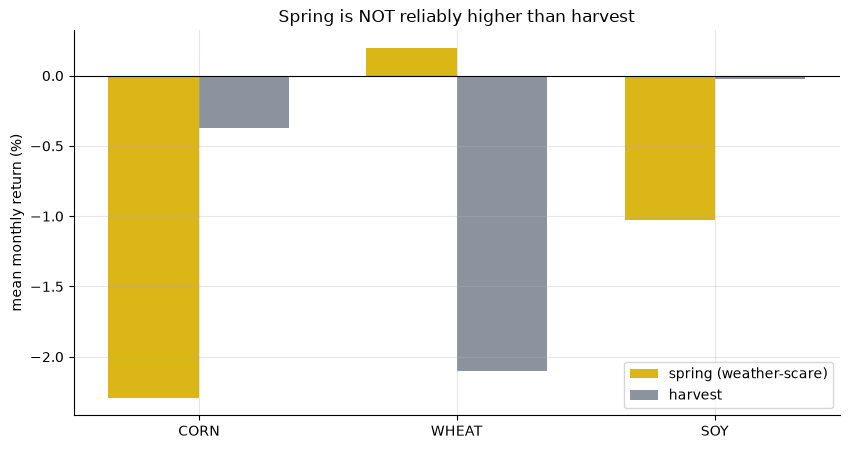

{'corn': (-2.29, -0.38), 'wheat': (0.2, -2.1), 'soy': (-1.03, -0.02)}


In [2]:
grains = list(data.GRAINS)
if HAVE_REAL:
    sh = {g: st.spring_harvest_tstat(MONTHLY[g], data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g]) for g in grains}
    spring_v = [sh[g]['spring_mean']*100 for g in grains]
    harvest_v = [sh[g]['harvest_mean']*100 for g in grains]
else:
    spring_v = [R['sh'][g][0] for g in grains]
    harvest_v = [R['sh'][g][2] for g in grains]
x = np.arange(len(grains)); w = 0.35
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(x - w/2, spring_v, w, label='spring (weather-scare)', color=AMBER)
ax.bar(x + w/2, harvest_v, w, label='harvest', color=GREY)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([g.upper() for g in grains])
ax.set_ylabel('mean monthly return (%)')
ax.set_title('Spring is NOT reliably higher than harvest')
ax.legend(); plt.tight_layout(); plt.show()
print({g: (round(spring_v[i],2), round(harvest_v[i],2)) for i,g in enumerate(grains)})

Two of three bars are the *wrong* way round: corn and soy actually average **less** in their spring window than in their harvest window — the opposite of the legend. Only wheat points the claimed direction, and it's a small, noisy gap. Pool all three grains and the spread is **-0.17%/month** — practically nothing, with an uncertainty band from **-2.0%** to **+1.8%** that comfortably contains zero (and the *opposite* sign).

**Next, the full calendar.** Which single month is best, for each grain?

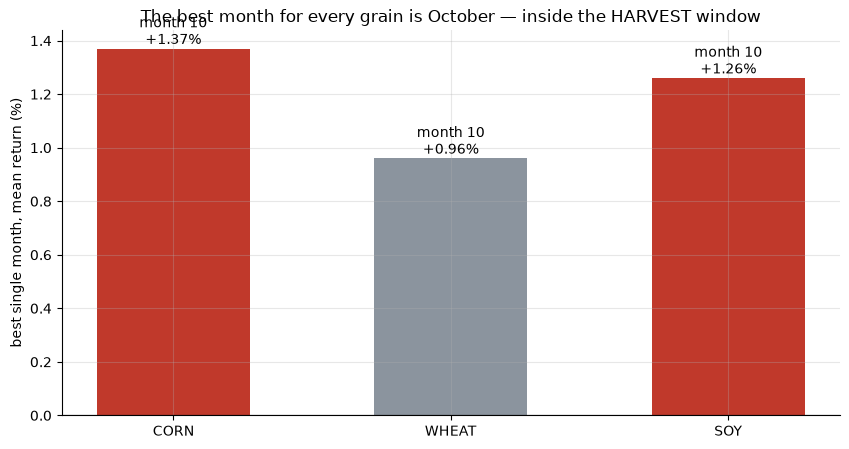

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
months = [R['best'][g][0] for g in grains]
means = [R['best'][g][1] for g in grains]
cols = [RED if m in data.HARVEST_MONTHS[g] else (AMBER if m in data.SPRING_MONTHS[g] else GREY)
        for g, m in zip(grains, months)]
ax.bar([g.upper() for g in grains], means, color=cols, width=.55)
for i, (m, v) in enumerate(zip(months, means)):
    ax.annotate(f'month {m}\n{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('best single month, mean return (%)')
ax.set_title('The best month for every grain is October — inside the HARVEST window')
plt.tight_layout(); plt.show()

October — the tail end of the calendar's own harvest window — is the single best month for **all three grains**. That's the opposite of "harvest is the low": if anything, the calendar's low shows up mid-harvest (September) and *recovers* by its own final month. None of these individual months, best or worst, clears a strict bar that accounts for testing 36 different month/grain combinations at once — a single standout cell out of 36 draws is exactly what you'd expect from chance alone, and none of ours even reaches that lower bar.

**Now, the trade.** Long spring, short harvest, cash otherwise — does it beat just holding the ETF?

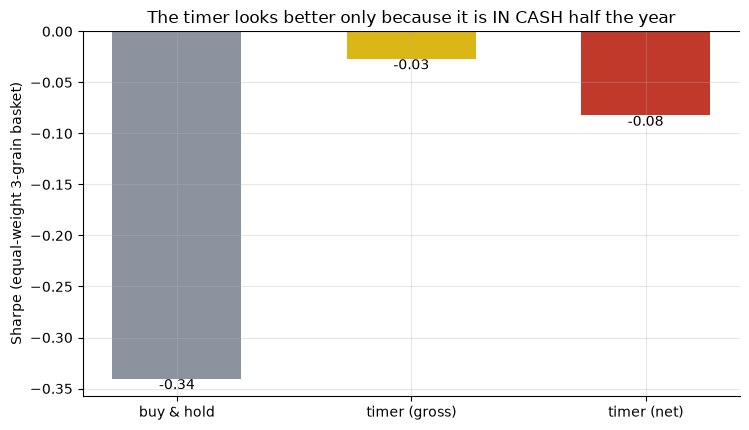

buy&hold -0.34   timer gross -0.03   timer net -0.08


In [4]:
if HAVE_REAL:
    pooled_bh = sum(MONTHLY[g].reindex(MONTHLY['corn'].index) for g in grains) / 3
    pooled_timer = sum(st.seasonal_timer(MONTHLY[g], data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g]) for g in grains) / 3
    pooled_net = st.apply_costs(pooled_timer, n_trades_per_year=4, cost_bps_one_way=10.0)
    bh, tg, tn = st.summary(pooled_bh)['sharpe'], st.summary(pooled_timer)['sharpe'], st.summary(pooled_net)['sharpe']
else:
    bh, tg, tn = R['timer']['pooled'][0], R['timer']['pooled'][2], R['timer']['pooled'][4]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['buy & hold', 'timer (gross)', 'timer (net)'], [bh, tg, tn], color=[GREY, AMBER, RED], width=.55)
for i, v in enumerate([bh, tg, tn]): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe (equal-weight 3-grain basket)')
ax.set_title('The timer looks better only because it is IN CASH half the year')
plt.tight_layout(); plt.show()
print(f'buy&hold {bh:+.2f}   timer gross {tg:+.2f}   timer net {tn:+.2f}')

The timer's Sharpe does creep above buy-and-hold — but that's a magic trick, not a discovery: the timer sits in cash 5 months a year, and this basket of grain ETFs has *lost money on average since 2011*. Doing less of a losing trade looks better almost by definition. The honest test is to check **only the months the trade is actually on**: those active months win **46%** of the time, pooled across all three grains — a coin flip, and a slightly unlucky one. Even after costs, the net Sharpe is still negative.

**Finally, the hidden cost.** Even if the calendar edge were real, can you actually collect it in the ETF, or does the ETF's own machinery eat it first?

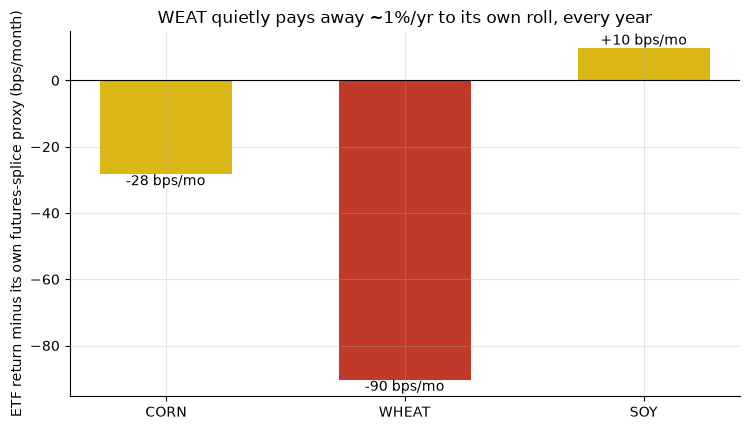

{'corn': -28.3, 'wheat': -90.3, 'soy': 9.8}


In [5]:
gs = grains
if HAVE_REAL:
    drags = [st.roll_drag(MONTHLY[g], FUT_MONTHLY[g])['drag_bps'] for g in gs]
else:
    drags = [R['drag'][g][2] for g in gs]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar([g.upper() for g in gs], drags, color=[RED if d < -30 else AMBER for d in drags], width=.55)
for i, v in enumerate(drags): ax.annotate(f'{v:+.0f} bps/mo', (i, v), ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel("ETF return minus its own futures-splice proxy (bps/month)")
ax.set_title('WEAT quietly pays away ~1%/yr to its own roll, every year')
plt.tight_layout(); plt.show()
print({g: round(d,1) for g, d in zip(gs, drags)})

WEAT gives back **90 basis points a month** — about **1.1% a year** — to its own rolling mechanics, relative to a simple futures-price proxy, regardless of any calendar view you might have. That drag alone is bigger than every spring-vs-harvest spread this study measured. Whatever seasonal edge exists in the raw futures curve, a WEAT holder pays most of it away before the calendar even gets a vote.

## 5 · The verdict

- **Signal — None.** No calendar month, in any of the three grains, clears the bar once you account for testing 36 things at once. Two of three grains point *against* the legend, and the best month for every grain sits inside the harvest window, not the spring window.
- **Tradability — Mirage.** The seasonal timer's apparent improvement is a cash-drag artifact, not skill (its active months hit at coin-flip odds), and WEAT's own roll costs more than the entire theoretical edge is worth.
- **"Beats a coin?" — Busted.** The trade's active legs win 46% of the time — worse than a fair coin, not better.

## 6 · Going further 🚪

- **The mechanism might still be real in the futures curve** — this study tests the *ETF*, the thing you can actually buy, not the raw contract-to-contract basis. The next step would be measuring the calendar spread directly in the futures term structure, the way [639-gasoline-rvp-seasonality](../../639-gasoline-rvp-seasonality/) does for gasoline's *statutory* deadline.
- **Weather years might matter more than calendar months.** A single bad drought (2012) can dominate 15 years of "average June," and averaging it away is exactly what a clean seasonality test is supposed to do — which is one reason this one comes up empty.
- **Sibling studies:** [307-coffee-seasonality](../../307-coffee-seasonality/) (a frost story, not a planting story) and [651-sugar-seasonality](../../651-sugar-seasonality/) (a different crush cycle) ask the same shape of question about different crops — worth comparing notes.

*Think the calendar edge is real somewhere this study didn't look — the raw futures curve, a specific weather year, a different window? Show a net, certifiable edge on a tradable instrument, then we'll talk.*